In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from GG4 import Brain

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))
sys.path.insert(0, str(Path("../..").resolve()))

from BMI_and_Hand import BMI_and_Hand

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    ARM_LINK,
    BANDS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    ERA_EM_4_PATH,
    MAX_DELTA,
    N_BURNIN,
    RANDOM_SEED,
    SystemEstimate,
    SystemModel,
    calibrate_gains,
    calibrate_gains_closed_loop,
    compute_crosstalk,
    estimate_x1_proj,
)
from gain_matrix import (
    NOTEBOOK_GITHUB_URL,
    make_gain_matrix_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
T_CALIB = 800  # steps per calibration trial
T_WARMUP_CALIB = 200  # steps to discard before measuring gain
A_CALIB = 0.45  # sinusoidal amplitude for open-loop (u drive; keeps u ∈ [0,1])
A_CALIB_CL = 2.0  # sinusoidal amplitude for closed-loop (observation-space target)
T_X1_EST = 600  # steps for x1 projection estimation

# LQI weights for closed-loop calibration (match CartesianLQIController defaults)
Q_TRACK_CALIB = 10.0
R_EFFORT_CALIB = 80.0
Q_INT_CALIB = 0.5

# Which gain matrix to use in the cartesian_control cache
# 'open_loop' or 'closed_loop'
GAIN_MATRIX = "closed_loop"

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
# Load the identified band frequencies
bands_data = np.load(BANDS_PATH)
band_freqs: list[float] = bands_data["freqs"].tolist()
band_names: list[str] = bands_data["labels"].tolist()

print("Band frequencies (cyc/step):")
for name, freq in zip(band_names, band_freqs):
    print(f"  {name:6s}  f = {freq:.5f}  (ω = {2 * np.pi * freq:.4f} rad/step)")

# Load ERA+EM model and estimate y_mean from a neutral burn-in.
# y_mean is the operating-point mean observation used by the Kalman filter
# in the evaluation controller; it is NOT used in calibration.
est = SystemEstimate.load(ERA_EM_4_PATH)

print(f"\nEstimating y_mean from {N_BURNIN}-step burn-in (seed {RANDOM_SEED})...")
brain_bi = Brain(random_seed=RANDOM_SEED)
bmi_bi = BMI_and_Hand(brain_bi)
burn_ys = []
for _ in range(N_BURNIN):
    burn_ys.append(np.array(brain_bi.measure()))
    bmi_bi.next_state([0.5, 0.5])
y_mean = np.mean(burn_ys, axis=0)
print(f"y_mean: mean={y_mean.mean():.4f}, std={y_mean.std():.4f}")

model = SystemModel.from_estimate(est, y_mean=y_mean)
target_offset = float(model.base_mean)
print(f"target_offset (base_mean): {target_offset:.4f}")

Band frequencies (cyc/step):
  S$+$    f = 0.06784  (ω = 0.4263 rad/step)
  S$-$    f = 0.12414  (ω = 0.7800 rad/step)
  E$+$    f = 0.20700  (ω = 1.3006 rad/step)
  E$-$    f = 0.30968  (ω = 1.9458 rad/step)

Estimating y_mean from 500-step burn-in (seed 0)...
y_mean: mean=4.7068, std=0.4940
target_offset (base_mean): 4.7068


In [4]:
# ── 4. Simulation — open-loop gain calibration ────────────────────────────────
# One trial per band × channel combination: u0 = 0.5 + A_CALIB * sin(2π f t).
# Expected: M[0, :2] large (S± → shoulder), M[1, 2:] large (E± → elbow),
# with small off-diagonal cross-terms.
print(
    f"Running open-loop gain calibration: {len(band_freqs)} bands, seed {RANDOM_SEED}"
)

M_ol, best_channels = calibrate_gains(
    band_freqs,
    seed=RANDOM_SEED,
    t_calib=T_CALIB,
    t_warmup=T_WARMUP_CALIB,
    a_calib=A_CALIB,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    return_best_channels=True,
)

xt_ol = compute_crosstalk(M_ol)
print("\nOpen-loop crosstalk  (|secondary| / |primary|):")
for name, xt in zip(band_names, xt_ol):
    print(f"  {name:6s}  {xt:.1%}")

Running open-loop gain calibration: 4 bands, seed 0


Gain calibration:   0%|          | 0/16 [00:00<?, ?trial/s]


Gain matrix M  (rad / amplitude unit)
              S$+$      S$-$      E$+$      E$-$
  shoulder    6.8865   -6.9227    1.2994    1.3115
  elbow       0.0000    0.0000    6.8193   -5.7491

Best channel per band:
  S$+$    u0
  S$-$    u0m
  E$+$    u0
  E$-$    u01

Selectivity ratios:
  S bands: shoulder / elbow = 454625.84  (expect >> 1)
  E bands: elbow / shoulder = 4.81  (expect >> 1)

Open-loop crosstalk  (|secondary| / |primary|):
  S$+$    0.0%
  S$-$    0.0%
  E$+$    19.1%
  E$-$    22.8%


In [5]:
# ── 4a. Offline characterisation — x1 projection estimation ───────────────────
# Drives u0 sinusoidally at each band frequency and extracts the FFT direction
# of the neural observations at that frequency.  Averaging across bands gives
# the observation-space footprint of x1 — the frequency-encoding latent — which
# the closed-loop LQI must track to drive muscle selection.
print(f"Estimating x1 projection (T={T_X1_EST} steps, seed {RANDOM_SEED})...")

x1_proj = estimate_x1_proj(
    band_freqs,
    seed=RANDOM_SEED,
    t_est=T_X1_EST,
    amp=A_CALIB,
)
print(
    f"x1_proj: norm={np.linalg.norm(x1_proj):.4f}, top-3 channels: "
    + ", ".join(f"ch{i}" for i in np.argsort(np.abs(x1_proj))[::-1][:3])
)

Estimating x1 projection (T=600 steps, seed 0)...
x1_proj: norm=0.8136, top-3 channels: ch12, ch14, ch13


In [6]:
# ── 4b. Simulation — closed-loop gain calibration ─────────────────────────────
# For each band frequency an LQI controller tracks a sinusoidal target projected
# onto the shared x1 direction estimated in 4a.  Using the x1 projection (rather
# than per-band FFT amplitudes) correctly drives the frequency-encoding latent
# and produces well-calibrated elbow gains.
print(
    f"Running closed-loop gain calibration: {len(band_freqs)} bands, seed {RANDOM_SEED}"
)

M_cl = calibrate_gains_closed_loop(
    band_freqs,
    A=model.A,
    B=model.B,
    C=model.C,
    Q_mat=model.Q,
    R_mat=model.R,
    y_mean=y_mean,
    x1_proj=x1_proj,
    seed=RANDOM_SEED,
    t_calib=T_CALIB,
    t_warmup=T_WARMUP_CALIB,
    a_calib=A_CALIB_CL,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    q_track=Q_TRACK_CALIB,
    r_effort=R_EFFORT_CALIB,
    q_int=Q_INT_CALIB,
)

xt_cl = compute_crosstalk(M_cl)
print("\nClosed-loop crosstalk  (|secondary| / |primary|):")
for name, xt in zip(band_names, xt_cl):
    print(f"  {name:6s}  {xt:.1%}")

print("\nCrosstalk change (CL − OL, negative = improvement):")
for name, xt_o, xt_c in zip(band_names, xt_ol, xt_cl):
    print(f"  {name:6s}  {xt_c - xt_o:+.1%}")

Running closed-loop gain calibration: 4 bands, seed 0


Closed-loop gain calibration:   0%|          | 0/4 [00:00<?, ?trial/s]

  sign-corrected E$-$

Closed-loop gain matrix M_cl  (rad / obs. a.u.)
              S$+$      S$-$      E$+$      E$-$
  shoulder    1.5516   -1.5591    0.5476    0.5461
  elbow       0.0000    0.0000    1.5602   -1.4757

Selectivity ratios (closed-loop):
  S bands: shoulder / elbow = 389449.66  (expect >> 1)
  E bands: elbow / shoulder = 2.78  (expect >> 1)

Closed-loop crosstalk  (|secondary| / |primary|):
  S$+$    0.0%
  S$-$    0.0%
  E$+$    35.1%
  E$-$    37.0%

Crosstalk change (CL − OL, negative = improvement):
  S$+$    -0.0%
  S$-$    +0.0%
  E$+$    +16.0%
  E$-$    +14.2%


In [7]:
# ── 4c. Cache save ───────────────────────────────────────────────────────────
_M_choices = {"open_loop": M_ol, "closed_loop": M_cl}
if GAIN_MATRIX not in _M_choices:
    raise ValueError(
        f"GAIN_MATRIX must be 'open_loop' or 'closed_loop', got {GAIN_MATRIX!r}"
    )
M_cache = _M_choices[GAIN_MATRIX]

CARTESIAN_CONTROL_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    CARTESIAN_CONTROL_CACHE_PATH,
    band_freqs=np.array(band_freqs),
    gain_matrix=M_cache,
    y_mean=y_mean,
    target_offset=np.array(target_offset),
    x1_proj=x1_proj,
)
print(f"Cache saved ({GAIN_MATRIX}) → {CARTESIAN_CONTROL_CACHE_PATH}")

Cache saved (closed_loop) → /Users/tahmidazam/Developer/gg4/data/cartesian_control_cache.npz


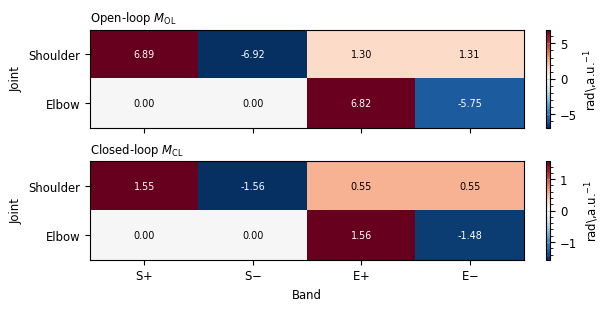

In [8]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_gain_matrix_figure(M_ol, M_cl, band_freqs, band_names, figsize=(6, 3))
apply_figure_style(fig)
plt.show()

In [9]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.5
FIG_HEIGHT_FRAC = 0.2

configure_pgf()
fig = make_gain_matrix_figure(
    M_ol,
    M_cl,
    band_freqs,
    band_names,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "gain_matrix.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/gain_matrix.pgf


In [10]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
band_str = ", ".join(
    f"{name} ($f={freq:.3f}$ cyc\\,step\\textsuperscript{{--1}})"
    for name, freq in zip(band_names, band_freqs)
)


def _xt_str(xt):
    return ", ".join(f"{name}\\,{v:.0%}" for name, v in zip(band_names, xt))


caption = (
    r"Gain matrices $M_\mathrm{OL}, M_\mathrm{CL} \in \mathbb{R}^{2 \times 4}$ "
    f"calibrated from open-loop (OL) and closed-loop LQI (CL) trials "
    f"($T={T_CALIB}$ steps, warmup ${T_WARMUP_CALIB}$ steps, seed {RANDOM_SEED})."
)

save_caption(CAPTIONS_PATH / "gain_matrix.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/gain_matrix.tex
Gain matrices $M_\mathrm{OL}, M_\mathrm{CL} \in \mathbb{R}^{2 \times 4}$ calibrated from open-loop (OL) and closed-loop LQI (CL) trials ($T=800$ steps, warmup $200$ steps, seed 0).
